# ITP_14

## 0. Setup & Credentials

In [ ]:
!pip install onnxmltools onnxruntime

In [ ]:
import json, os, time, pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import onnxmltools
import onnxruntime as ort
from onnxmltools.convert.common.data_types import FloatTensorType

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier

!pip install -q kaggle onnxmltools onnxruntime shap

try:
    from google.colab import userdata
    kaggle_username = userdata.get('KAGGLE_USERNAME')
    kaggle_api_token = userdata.get('KAGGLE_KEY')
except Exception:
    kaggle_username = "INSERT_USERNAME"
    kaggle_api_token = "INSERT_TOKEN"

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": kaggle_username, "key": kaggle_api_token}, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

## 1. Download Dataset

In [ ]:
os.makedirs("/content/data", exist_ok=True)
exit_code = os.system("kaggle datasets download -d mathchi/online-retail-ii-uci -p /content/data --unzip")

if exit_code != 0 or not os.listdir("/content/data"):
    os.makedirs("/content/data_2009_2010", exist_ok=True)
    os.makedirs("/content/data_2010_2011", exist_ok=True)
    os.system("kaggle datasets download -d nathaniel/uci-online-retail-ii-data-set -p /content/data_2009_2010 --unzip")
    os.system("kaggle datasets download -d kabilan45/online-retail-ii-dataset -p /content/data_2010_2011 --unzip")

print("data:", os.listdir("/content/data") if os.path.exists("/content/data") else "fallback used")

data: []


## 2. Load & Inspect Data

In [ ]:
combined_path = next(
    (os.path.join("/content/data", f) for f in os.listdir("/content/data")
     if f.lower().endswith(('.csv', '.xlsx'))),
    None
)

if combined_path:
    df = pd.read_csv(combined_path, encoding='ISO-8859-1') if combined_path.endswith('.csv') else pd.read_excel(combined_path)
else:
    frames = [
        pd.read_csv(os.path.join(folder, f), encoding='ISO-8859-1') if f.endswith('.csv')
        else pd.read_excel(os.path.join(folder, f))
        for folder in ["/content/data_2009_2010", "/content/data_2010_2011"]
        for f in os.listdir(folder) if f.lower().endswith(('.csv', '.xlsx'))
    ]
    df = pd.concat(frames, ignore_index=True)

print("Raw rows:", len(df))
print("Columns:", df.columns.tolist())
df.head()

Raw rows: 1050922
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2.5 Dataset Span Diagnostic

In [ ]:
_dates = pd.to_datetime(df['InvoiceDate'])
print("Raw date range:", _dates.min(), "to", _dates.max())
for yr in [2009, 2010, 2011]:
    print(f"Rows in {yr}: {(_dates.dt.year == yr).sum():,}")

n, half = len(df), len(df) // 2
first_half = df.iloc[:half].reset_index(drop=True)
second_half = df.iloc[half:2*half].reset_index(drop=True)
identical = first_half.equals(second_half)
print(f"\nTotal raw rows: {n:,}  |  First half == second half: {identical}")

print("\nDuplicate group size distribution:")
print(df.groupby(list(df.columns), dropna=False).size().value_counts().sort_index())

Raw date range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00
Rows in 2009: 90,456
Rows in 2010: 960,466
Rows in 2011: 0

Total raw rows: 1,050,922  |  First half == second half: True

Duplicate group size distribution:
2     512178
4       6037
6        330
8         40
10         7
12         4
Name: count, dtype: int64


## 3. Data Cleaning

In [ ]:
df.columns = df.columns.str.strip()
df = df.rename(columns={k: v for k, v in {
    'CustomerID': 'Customer ID', 'Customer_ID': 'Customer ID',
    'InvoiceNo': 'Invoice', 'UnitPrice': 'Price'
}.items() if k in df.columns})

clean_log = {
    "raw_rows": len(df),
    "missing_raw": {k: int(v) for k, v in df.isnull().sum().items() if v > 0},
}

df = df.dropna(subset=['Customer ID'])
clean_log["after_drop_null_id"] = len(df)
df = df[~df['Invoice'].astype(str).str.startswith('C')]
clean_log["after_remove_cancellations"] = len(df)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
clean_log["after_remove_negatives"] = len(df)
before = len(df)
df = df.drop_duplicates()
clean_log["after_dedup"] = len(df)
clean_log["duplicates_removed"] = before - len(df)
clean_log["unique_customers"] = int(df['Customer ID'].nunique())

for k, v in clean_log.items():
    print(f"{k}: {v:,}" if isinstance(v, int) else f"{k}: {v}")

raw_rows: 1,050,922
missing_raw: {'Description': 5856, 'Customer ID': 215854}
after_drop_null_id: 835,068
after_remove_cancellations: 815,390
after_remove_negatives: 815,328
after_dedup: 400,916
duplicates_removed: 414,412
unique_customers: 4,312


## 4. Exploratory Data Analysis

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['Price']

print("Date range:", df['InvoiceDate'].min().date(), "to", df['InvoiceDate'].max().date())
print(f"Total revenue: £{df['Revenue'].sum():,.2f}")
print("\nTop 10 countries:\n", df['Country'].value_counts().head(10))

invoices_per_customer = df.groupby('Customer ID')['Invoice'].nunique()
print("\nInvoices per customer:\n", invoices_per_customer.describe())
print("Single-invoice customers:", (invoices_per_customer == 1).sum())

Date range: 2009-12-01 to 2010-12-09
Total revenue: £8,798,233.74

Top 10 countries:
 Country
United Kingdom    364233
EIRE                8503
Germany             7645
France              5452
Netherlands         2728
Spain               1228
Switzerland         1170
Belgium             1036
Portugal             983
Sweden               867
Name: count, dtype: int64

Invoices per customer:
 count    4312.000000
mean        4.455705
std         8.170213
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       205.000000
Name: Invoice, dtype: float64
Single-invoice customers: 1419


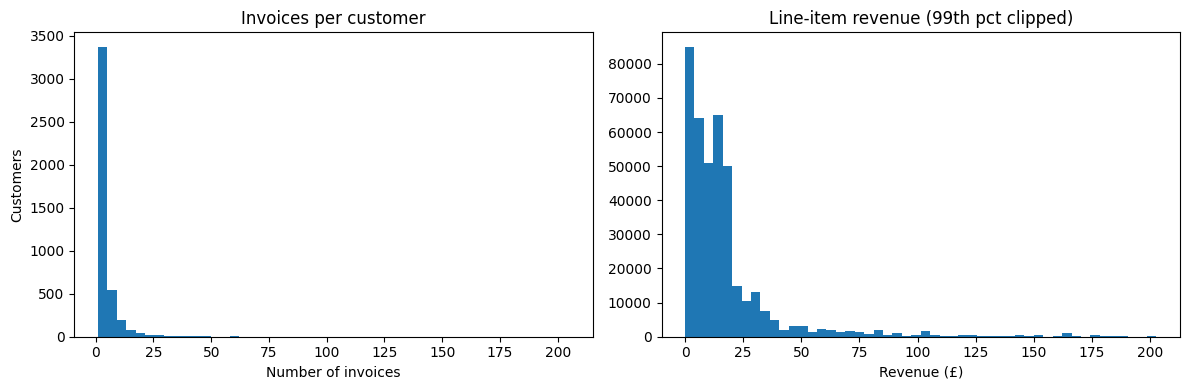

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(invoices_per_customer, bins=50)
axes[0].set(title='Invoices per customer', xlabel='Number of invoices', ylabel='Customers')
axes[1].hist(df['Revenue'], bins=50, range=(0, df['Revenue'].quantile(0.99)))
axes[1].set(title='Line-item revenue (99th pct clipped)', xlabel='Revenue (£)')
plt.tight_layout()
plt.show()

## 5. Purchase Cadence Analysis

Median days between purchases: 20.0
Mean days between purchases:   38.4


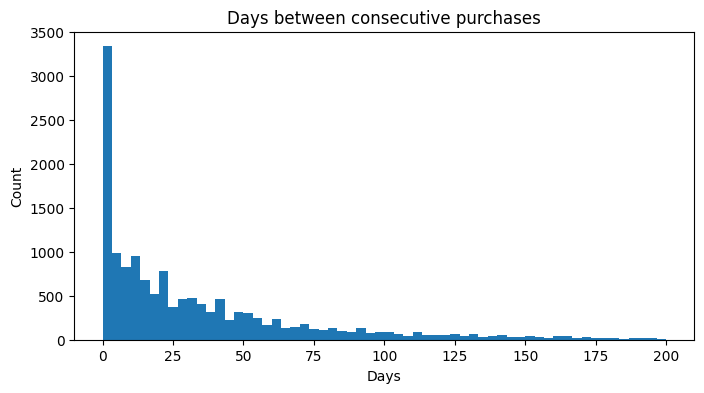

In [ ]:
invoice_dates = df.groupby(['Customer ID', 'Invoice'])['InvoiceDate'].first().reset_index()
all_gaps = (
    invoice_dates.groupby('Customer ID')['InvoiceDate']
    .apply(lambda x: x.sort_values().diff().dt.days.dropna())
    .explode().dropna()
)

print(f"Median days between purchases: {all_gaps.median()}")
print(f"Mean days between purchases:   {all_gaps.mean():.1f}")

plt.figure(figsize=(8, 4))
plt.hist(all_gaps, bins=60, range=(0, 200))
plt.title('Days between consecutive purchases')
plt.xlabel('Days')
plt.ylabel('Count')
plt.show()

## 6. RFM Computation & Churn Labeling

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    last_purchase=('InvoiceDate', 'max'),
    frequency=('Invoice', 'nunique'),
    monetary=('Revenue', 'sum')
).reset_index()
rfm['recency'] = (snapshot_date - rfm['last_purchase']).dt.days

for t in [60, 90, 120]:
    rfm[f'churned_{t}'] = (rfm['recency'] > t).astype(int)
    churned = int(rfm[f'churned_{t}'].sum())
    print(f"{t}-day: churned={churned:,}, retained={len(rfm)-churned:,}, rate={rfm[f'churned_{t}'].mean():.2%}")

rfm.describe()

60-day: churned=1,935, retained=2,377, rate=44.87%
90-day: churned=1,435, retained=2,877, rate=33.28%
120-day: churned=1,174, retained=3,138, rate=27.23%


,Customer ID,last_purchase,frequency,monetary,recency,churned_60,churned_90,churned_120
count,4312.000000,4312,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,2010-09-10 09:08:37.138219008,4.455705,2040.406712,91.171846,0.448748,0.332792,0.272263
min,12346.000000,2009-12-01 09:55:00,1.000000,2.950000,1.000000,0.000000,0.000000,0.000000
25%,13882.500000,2010-07-27 09:53:00,1.000000,307.187500,18.000000,0.000000,0.000000,0.000000
50%,15350.500000,2010-10-18 16:34:30,2.000000,701.615000,53.000000,0.000000,0.000000,0.000000
75%,16834.250000,2010-11-22 11:01:30,5.000000,1714.932500,136.000000,1.000000,1.000000,1.000000
max,18287.000000,2010-12-09 20:01:00,205.000000,349164.350000,374.000000,1.000000,1.000000,1.000000
std,1701.200176,NaN,8.170213,8911.755977,96.860633,0.497424,0.471268,0.445176


## 6.5 Train/Predict Temporal Split for ML Labels

In [ ]:
cutoff_date = df['InvoiceDate'].max() - pd.Timedelta(days=90)
print("Cutoff date:", cutoff_date)

obs = df[df['InvoiceDate'] <= cutoff_date]
pred = df[df['InvoiceDate'] > cutoff_date]
print(f"Observation window: {len(obs):,} rows, {obs['Customer ID'].nunique():,} customers")
print(f"Prediction window:  {len(pred):,} rows, {pred['Customer ID'].nunique():,} customers")

rfm_ml = obs.groupby('Customer ID').agg(
    last_purchase=('InvoiceDate', 'max'),
    frequency=('Invoice', 'nunique'),
    monetary=('Revenue', 'sum'),
).reset_index()
rfm_ml['recency'] = (cutoff_date - rfm_ml['last_purchase']).dt.days

returning = set(pred['Customer ID'].unique())
rfm_ml['churned_90'] = (~rfm_ml['Customer ID'].isin(returning)).astype(int)

print(f"\nObservation-window customers: {len(rfm_ml):,}")
print(f"Churn rate: {rfm_ml['churned_90'].mean():.4f}")
print("\nRecency by churn label (expect overlap, not a clean cut at 90):")
print(rfm_ml.groupby('churned_90')['recency'].describe()[['mean', 'min', '50%', 'max']])

Cutoff date: 2010-09-10 20:01:00
Observation window: 253,543 rows, 3,377 customers
Prediction window:  147,373 rows, 2,877 customers

Observation-window customers: 3,377
Churn rate: 0.4249

Recency by churn label (expect overlap, not a clean cut at 90):
                  mean  min    50%    max
churned_90                               
0            75.489186  0.0   52.0  283.0
1           116.889199  0.0  108.0  283.0


### 6.6 Export Real Customer Sample for ChurnBenchmark App

Exports 100 real customer RFM profiles from `rfm_ml`, sampled uniformly at random (not
stratified by recency), to `customer_sample.json`. This replaces the hand-authored synthetic
test values previously used in the ChurnBenchmark Android app's benchmark seed data.
**Changed 19 July 2026** from an evenly-recency-spread sample (`np.linspace`) to a uniform
random sample, so the resulting tier distribution reflects the population's actual recency
distribution rather than an artificially even spread across risk tiers.

In [ ]:
import json
import numpy as np

# Sample 100 real customers uniformly at random, so the benchmark set reflects
# the population's actual recency/risk-tier distribution rather than an
# artificially even spread (changed 19 July 2026, previously used np.linspace
# stratified by recency; see Decisions.md for why).
sample_customers = rfm_ml.sample(n=100, random_state=42).reset_index(drop=True)

export_rows = []
for _, row in sample_customers.iterrows():
    export_rows.append({
        "customer_id": str(row["Customer ID"]),
        "recency_days": int(row["recency"]),
        "frequency": int(row["frequency"]),
        "monetary": round(float(row["monetary"]), 2),
    })

with open("customer_sample.json", "w") as f:
    json.dump(export_rows, f, indent=2)

print(f"Exported {len(export_rows)} real customer profiles (uniform random sample)")
print(json.dumps(export_rows[:3], indent=2), "...")


Exported 100 real customer profiles (uniform random sample)
[
  {
    "customer_id": "18091.0",
    "recency_days": 138,
    "frequency": 1,
    "monetary": 360.85
  },
  {
    "customer_id": "12648.0",
    "recency_days": 185,
    "frequency": 2,
    "monetary": 311.8
  },
  {
    "customer_id": "14548.0",
    "recency_days": 29,
    "frequency": 7,
    "monetary": 1888.49
  }
] ...


## 7. Summary Report

In [ ]:
summary = {
    "raw_rows": clean_log["raw_rows"],
    "cleaned_rows": clean_log["after_dedup"],
    "duplicates_removed": clean_log["duplicates_removed"],
    "unique_customers": clean_log["unique_customers"],
    "date_range": [str(df['InvoiceDate'].min().date()), str(df['InvoiceDate'].max().date())],
    "median_days_between_purchases": round(float(all_gaps.median()), 1),
    "mean_days_between_purchases": round(float(all_gaps.mean()), 1),
    "churn_rates": {f"{t}_day": round(float(rfm[f'churned_{t}'].mean()), 4) for t in [60, 90, 120]},
    "churn_counts": {f"{t}_day": int(rfm[f'churned_{t}'].sum()) for t in [60, 90, 120]},
}
print(json.dumps(summary, indent=2))
with open('eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

{
  "raw_rows": 1050922,
  "cleaned_rows": 400916,
  "duplicates_removed": 414412,
  "unique_customers": 4312,
  "date_range": [
    "2009-12-01",
    "2010-12-09"
  ],
  "median_days_between_purchases": 20.0,
  "mean_days_between_purchases": 38.4,
  "churn_rates": {
    "60_day": 0.4487,
    "90_day": 0.3328,
    "120_day": 0.2723
  },
  "churn_counts": {
    "60_day": 1935,
    "90_day": 1435,
    "120_day": 1174
  }
}


## 9. Model Training

In [ ]:
rfm_ml["log_monetary"] = np.log1p(rfm_ml["monetary"])
feature_cols = ["recency", "frequency", "log_monetary"]
X = rfm_ml[feature_cols].copy()
y = rfm_ml["churned_90"].copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1765, stratify=y_train_full, random_state=42)
print(f"train={len(X_train)} val={len(X_val)} test={len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

def evaluate(name, y_true, y_pred, y_proba):
    return {"Model": name,
            "Accuracy":  accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall":    recall_score(y_true, y_pred, zero_division=0),
            "F1":        f1_score(y_true, y_pred, zero_division=0),
            "AUC":       roc_auc_score(y_true, y_proba)}

lr = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_scaled, y_train)

xgb_default = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, eval_metric="logloss", random_state=42)
xgb_default.fit(X_train, y_train)

X_train_res, y_train_res = SMOTEENN(random_state=42).fit_resample(X_train, y_train)
print(f"After SMOTE-ENN: {len(X_train_res)} rows ({y_train_res.mean():.4f})")

xgb_smoteenn = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, eval_metric="logloss", random_state=42)
xgb_smoteenn.fit(X_train_res, y_train_res)

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    {"learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
     "max_depth": [3, 5, 7, 10],
     "n_estimators": [100, 200, 300, 500]},
    scoring="recall", cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), n_jobs=-1,
)
grid.fit(X_train_res, y_train_res)
print(f"Best params: {grid.best_params_}")
tuned_model = grid.best_estimator_

X_train_res_scaled = scaler.transform(X_train_res)
lr_smoteenn = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_res_scaled, y_train_res)

val_results = [
    evaluate("LogReg baseline",         y_val, lr.predict(X_val_scaled),       lr.predict_proba(X_val_scaled)[:, 1]),
    evaluate("SMOTE-ENN + LogReg",      y_val, lr_smoteenn.predict(X_val_scaled), lr_smoteenn.predict_proba(X_val_scaled)[:, 1]),
    evaluate("XGBoost default",         y_val, xgb_default.predict(X_val),     xgb_default.predict_proba(X_val)[:, 1]),
    evaluate("SMOTE-ENN + XGB default", y_val, xgb_smoteenn.predict(X_val),    xgb_smoteenn.predict_proba(X_val)[:, 1]),
    evaluate("SMOTE-ENN + XGB tuned",   y_val, tuned_model.predict(X_val),     tuned_model.predict_proba(X_val)[:, 1]),
]
val_df = pd.DataFrame(val_results)
for col in ["Accuracy", "Precision", "Recall", "F1", "AUC"]:
    val_df[col] = (val_df[col] * 100).round(2)
print("\nValidation set:\n", val_df.to_string(index=False))

train=2363 val=507 test=507
After SMOTE-ENN: 930 rows (0.5097)
Best params: {'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 100}

Validation set:
                   Model  Accuracy  Precision  Recall    F1   AUC
        LogReg baseline     69.23      64.15   62.96 63.55 73.85
     SMOTE-ENN + LogReg     67.46      58.76   79.17 67.46 73.81
        XGBoost default     65.09      59.51   56.48 57.96 70.92
SMOTE-ENN + XGB default     64.89      56.93   72.22 63.67 72.40
  SMOTE-ENN + XGB tuned     65.09      57.20   71.76 63.66 71.54


### 9.1 Resampling Technique Comparison (this project's own RFM data)

SMOTE-ENN was carried over from the Y2T2 project's 8-condition comparison on the IBM Telco
dataset. That comparison was never re-run on this project's own retail RFM features, which
have a different feature distribution and class balance mechanics. This cell repeats the
comparison directly on `rfm_ml`, using the same default-XGBoost architecture as `xgb_default`
above, so the resampling choice is validated on the data it is actually used for.

In [ ]:
from imblearn.over_sampling import RandomOverSampler, ADASYN, SMOTE

resamplers = {
    "No resampling":       None,
    "Random Oversampling": RandomOverSampler(random_state=42),
    "ADASYN":               ADASYN(random_state=42),
    "SMOTE":                SMOTE(random_state=42),
    "SMOTE-ENN":            SMOTEENN(random_state=42),
}

resample_results = []
for name, sampler in resamplers.items():
    if sampler is None:
        Xr, yr = X_train, y_train
    else:
        try:
            Xr, yr = sampler.fit_resample(X_train, y_train)
        except Exception as e:
            print(f"{name}: failed ({e})")
            continue
    m = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                       eval_metric="logloss", random_state=42)
    m.fit(Xr, yr)
    row = evaluate(name, y_val, m.predict(X_val), m.predict_proba(X_val)[:, 1])
    row["Resampled n"] = len(Xr)
    resample_results.append(row)

resample_df = pd.DataFrame(resample_results)
for col in ["Accuracy", "Precision", "Recall", "F1", "AUC"]:
    resample_df[col] = (resample_df[col] * 100).round(2)
resample_df = resample_df.sort_values("Recall", ascending=False)
print("Resampling comparison, validated on this project's own RFM data (default XGBoost, validation set):\n")
print(resample_df.to_string(index=False))
print(f"\nSelected for this project: SMOTE-ENN {'confirmed best on recall' if resample_df.iloc[0]['Model'] == 'SMOTE-ENN' else 'NOT best on recall here, see result above, reconsider resampling choice'}")

Resampling comparison, validated on this project's own RFM data (default XGBoost, validation set):

              Model  Accuracy  Precision  Recall    F1   AUC  Resampled n
          SMOTE-ENN     64.89      56.93   72.22 63.67 72.40          930
Random Oversampling     66.07      58.53   69.91 63.71 71.64         2718
              SMOTE     67.26      60.00   69.44 64.38 71.04         2718
             ADASYN     65.68      58.75   65.28 61.84 71.31         2560
      No resampling     65.09      59.51   56.48 57.96 70.92         2363

Selected for this project: SMOTE-ENN confirmed best on recall


### 9.2 Lightweight Model

In [ ]:
def model_size_kb(model):
    return len(pickle.dumps(model)) / 1024

candidates = {
    "tuned (baseline)": tuned_model,
    "small_50":         XGBClassifier(n_estimators=50,  max_depth=3, learning_rate=0.1,  eval_metric="logloss", random_state=42),
    "small_30":         XGBClassifier(n_estimators=30,  max_depth=5, learning_rate=0.1,  eval_metric="logloss", random_state=42),
    "small_20_depth2":  XGBClassifier(n_estimators=20,  max_depth=2, learning_rate=0.15, eval_metric="logloss", random_state=42),
}

light_results = []
for name, model in candidates.items():
    if name != "tuned (baseline)":
        model.fit(X_train_res, y_train_res)
    row = evaluate(name, y_val, model.predict(X_val), model.predict_proba(X_val)[:, 1])
    row["SizeKB"] = round(model_size_kb(model), 1)
    light_results.append(row)

light_df = pd.DataFrame(light_results)
for col in ["Accuracy", "Precision", "Recall", "F1", "AUC"]:
    light_df[col] = (light_df[col] * 100).round(2)
print("Validation set (model selection):\n", light_df.to_string(index=False))

chosen_name = light_df.sort_values(["AUC", "SizeKB"], ascending=[False, True]).iloc[0]["Model"]
chosen_model = candidates[chosen_name]
print(f"\nSelected: {chosen_name}")

final = evaluate(f"FINAL: {chosen_name}", y_test, chosen_model.predict(X_test), chosen_model.predict_proba(X_test)[:, 1])
final_df = pd.DataFrame([final])
for col in ["Accuracy", "Precision", "Recall", "F1", "AUC"]:
    final_df[col] = (final_df[col] * 100).round(2)
print("\nTest set (reported once):\n", final_df.to_string(index=False))
print(confusion_matrix(y_test, chosen_model.predict(X_test)))

final_probs = chosen_model.predict_proba(X_test)[:, 1]
for tau in [0.65, 0.75]:
    preds_at_tau = (final_probs >= tau).astype(int)
    prec = precision_score(y_test, preds_at_tau, zero_division=0)
    rec = recall_score(y_test, preds_at_tau, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_at_tau).ravel()
    print(f"\nτ={tau}: Precision={prec*100:.2f}%  Recall={rec*100:.2f}%  FP={fp}  FN={fn}")

Validation set (model selection):
            Model  Accuracy  Precision  Recall    F1   AUC  SizeKB
tuned (baseline)     65.09      57.20   71.76 63.66 71.54   170.4
        small_50     65.88      57.54   75.93 65.47 72.76    65.4
        small_30     65.68      57.66   73.15 64.49 71.39    66.5
 small_20_depth2     67.06      58.72   76.39 66.40 72.94    28.4

Selected: small_20_depth2

Test set (reported once):
                  Model  Accuracy  Precision  Recall    F1   AUC
FINAL: small_20_depth2     61.74      53.87   67.91 60.08 72.02
[[167 125]
 [ 69 146]]

τ=0.65: Precision=56.30%  Recall=66.51%  FP=111  FN=72

τ=0.75: Precision=60.85%  Recall=60.00%  FP=83  FN=86


### 9.3 Statistical Significance: Deployed Model vs. SMOTE-ENN + Logistic Regression

Section 9 shows SMOTE-ENN + Logistic Regression outperforming every XGBoost configuration
on validation recall and AUC, including the deployed `small_20_depth2` model. Before
treating that gap as a real finding rather than sampling noise, this cell runs McNemar's
test on the paired validation-set predictions, since both models are evaluated on the same
customers and McNemar's test is the correct test for paired binary classifier comparisons
(it does not assume independent samples, unlike a standard chi-square test).

In [ ]:
from scipy.stats import binomtest
# Paired predictions on the same validation customers
pred_deployed = chosen_model.predict(X_val)
pred_lr_smoteenn = lr_smoteenn.predict(X_val_scaled)
y_val_arr = y_val.to_numpy() if hasattr(y_val, "to_numpy") else np.asarray(y_val)

correct_deployed = (pred_deployed == y_val_arr)
correct_lr = (pred_lr_smoteenn == y_val_arr)

# Discordant pairs: deployed correct & LR wrong (b), deployed wrong & LR correct (c)
b = int(np.sum(correct_deployed & ~correct_lr))   # deployed right, LR wrong
c = int(np.sum(~correct_deployed & correct_lr))   # deployed wrong, LR right
both_right = int(np.sum(correct_deployed & correct_lr))
both_wrong = int(np.sum(~correct_deployed & ~correct_lr))

print("McNemar contingency table (validation set, n=%d):" % len(y_val_arr))
print(f"  Both correct:            {both_right}")
print(f"  Deployed right, LR wrong: {b}")
print(f"  Deployed wrong, LR right: {c}")
print(f"  Both wrong:               {both_wrong}")

n_discordant = b + c
if n_discordant == 0:
    print("\nNo discordant pairs; models agree on every prediction, no test possible.")
else:
    # Exact two-sided binomial test on the discordant pairs (valid regardless of sample size,
    # preferred over the chi-square approximation when either discordant count is small)
    result = binomtest(min(b, c), n_discordant, 0.5, alternative="two-sided")
    print(f"\nMcNemar's exact test: p = {result.pvalue:.4f}")
    if result.pvalue < 0.05:
        print("Significant at alpha=0.05: the two models' error patterns differ systematically,")
        print("not by chance. The SMOTE-ENN + LR advantage over the deployed model is a real")
        print("finding, not sampling noise, given this validation set.")
    else:
        print("NOT significant at alpha=0.05: cannot reject the hypothesis that the deployed")
        print("model and SMOTE-ENN + LR perform equivalently on this validation set. The observed")
        print("recall/AUC gap may be within the range attributable to sampling variation at n=%d."
              % len(y_val_arr))

McNemar contingency table (validation set, n=507):
  Both correct:            327
  Deployed right, LR wrong: 13
  Deployed wrong, LR right: 15
  Both wrong:               152

McNemar's exact test: p = 0.8506
NOT significant at alpha=0.05: cannot reject the hypothesis that the deployed
model and SMOTE-ENN + LR perform equivalently on this validation set. The observed
recall/AUC gap may be within the range attributable to sampling variation at n=507.


### 9.4 Cost-Derived Rule Engine Threshold (Sensitivity Analysis)

The rule engine's 0.40/0.65 tier boundaries were set from RFM segmentation literature, not
fit to this project's own confusion matrix. This cell derives the threshold that minimises
expected cost, sweeping the cost ratio (cost of a missed churner : cost of an unnecessary
coupon) across the range implied by this project's own sourced figures: acquisition costing
5-7x more than retention (Saras Analytics), rather than asserting a single unsourced dollar
figure. This is a sensitivity analysis, not a point estimate, since no per-coupon dollar cost
was measured for this dataset.

In [ ]:
test_probs = chosen_model.predict_proba(X_test)[:, 1]
y_test_arr = y_test.to_numpy() if hasattr(y_test, "to_numpy") else np.asarray(y_test)

thresholds = np.arange(0.05, 0.96, 0.01)
cost_ratios = [3, 5, 7, 10, 15]  # FN_cost : FP_cost; 5-7x brackets the sourced Saras Analytics figure

print("Cost-minimising threshold per cost ratio (FN:FP), test set:\n")
sweep_rows = []
for ratio in cost_ratios:
    costs = []
    for tau in thresholds:
        preds = (test_probs >= tau).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test_arr, preds).ravel()
        expected_cost = ratio * fn + 1 * fp   # FP cost normalised to 1 unit
        costs.append(expected_cost)
    costs = np.array(costs)
    best_idx = costs.argmin()
    best_tau = thresholds[best_idx]
    preds_best = (test_probs >= best_tau).astype(int)
    prec = precision_score(y_test_arr, preds_best, zero_division=0)
    rec = recall_score(y_test_arr, preds_best, zero_division=0)
    sweep_rows.append({"Cost ratio (FN:FP)": f"{ratio}:1", "Optimal tau": round(float(best_tau), 2),
                        "Precision": round(prec*100, 2), "Recall": round(rec*100, 2),
                        "Min expected cost (units)": int(costs[best_idx])})

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.to_string(index=False))
print("\nCurrent rule engine boundaries: HIGH >= 0.65, LOW < 0.40 (MEDIUM in between).")
print("Compare the optimal-tau column above against 0.65 across the sourced 5-7x cost-ratio")
print("range to see whether the literature-derived boundary is close to the cost-minimising one.")


Cost-minimising threshold per cost ratio (FN:FP), test set:

Cost ratio (FN:FP)  Optimal tau  Precision  Recall  Min expected cost (units)
               3:1         0.06      49.88   95.35                        236
               5:1         0.06      49.88   95.35                        256
               7:1         0.05      46.10   99.07                        263
              10:1         0.05      46.10   99.07                        269
              15:1         0.05      46.10   99.07                        279

Current rule engine boundaries: HIGH >= 0.65, LOW < 0.40 (MEDIUM in between).
Compare the optimal-tau column above against 0.65 across the sourced 5-7x cost-ratio
range to see whether the literature-derived boundary is close to the cost-minimising one.


### 9.5 Bootstrap Confidence Intervals and Precision-Recall Curve

AUC and recall have so far been reported as point estimates only. This cell adds bootstrap
confidence intervals for test-set AUC and recall (percentile method, resampling the test
set with replacement), and a precision-recall curve, which is a more informative summary
than AUC-ROC alone given the class imbalance that motivated the SMOTE-ENN resampling in
the first place.

Test-set AUC:    0.7202  (95% bootstrap CI: [0.6757, 0.7642], n_boot=2000)
Test-set Recall: 0.6791  (95% bootstrap CI: [0.6157, 0.7374], n_boot=2000)

Average precision (area under PR curve): 0.6196


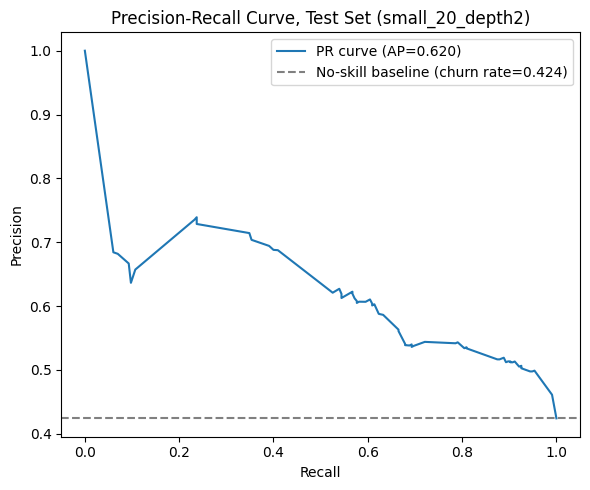

In [ ]:
from sklearn.metrics import roc_auc_score, recall_score as _recall_score, precision_recall_curve, average_precision_score

rng = np.random.default_rng(42)
y_test_arr = y_test.to_numpy() if hasattr(y_test, "to_numpy") else np.asarray(y_test)
test_probs_boot = chosen_model.predict_proba(X_test)[:, 1]
test_preds_boot = chosen_model.predict(X_test)

n_boot = 2000
n = len(y_test_arr)
boot_aucs = []
boot_recalls = []
for _ in range(n_boot):
    idx_boot = rng.integers(0, n, n)
    y_b = y_test_arr[idx_boot]
    if len(np.unique(y_b)) < 2:
        continue  # skip degenerate resamples with only one class present
    probs_b = test_probs_boot[idx_boot]
    preds_b = test_preds_boot[idx_boot]
    boot_aucs.append(roc_auc_score(y_b, probs_b))
    boot_recalls.append(_recall_score(y_b, preds_b, zero_division=0))

boot_aucs = np.array(boot_aucs)
boot_recalls = np.array(boot_recalls)

auc_point = roc_auc_score(y_test_arr, test_probs_boot)
recall_point = _recall_score(y_test_arr, test_preds_boot)

auc_ci = np.percentile(boot_aucs, [2.5, 97.5])
recall_ci = np.percentile(boot_recalls, [2.5, 97.5])

print(f"Test-set AUC:    {auc_point:.4f}  (95% bootstrap CI: [{auc_ci[0]:.4f}, {auc_ci[1]:.4f}], n_boot={len(boot_aucs)})")
print(f"Test-set Recall: {recall_point:.4f}  (95% bootstrap CI: [{recall_ci[0]:.4f}, {recall_ci[1]:.4f}], n_boot={len(boot_recalls)})")

# Precision-recall curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test_arr, test_probs_boot)
avg_precision = average_precision_score(y_test_arr, test_probs_boot)
print(f"\nAverage precision (area under PR curve): {avg_precision:.4f}")

plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve, label=f"PR curve (AP={avg_precision:.3f})")
baseline_rate = y_test_arr.mean()
plt.axhline(baseline_rate, linestyle="--", color="gray", label=f"No-skill baseline (churn rate={baseline_rate:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve, Test Set (small_20_depth2)")
plt.legend()
plt.tight_layout()
plt.savefig("pr_curve.png", dpi=150)
plt.show()


## 10. ONNX Export

In [ ]:
edge_model = XGBClassifier(**chosen_model.get_params())
edge_model.fit(X_train_res.values, np.asarray(y_train_res))  # ponytail: bare arrays required by onnxmltools XGBoost converter

X_test_np = X_test.values.astype(np.float32)
onnx_model = onnxmltools.convert_xgboost(edge_model, initial_types=[("float_input", FloatTensorType([None, X_test_np.shape[1]]))])
onnx_path = "churn_model_edge.onnx"
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"pickle: {model_size_kb(edge_model):.1f} KB  |  onnx: {os.path.getsize(onnx_path)/1024:.1f} KB")

session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name
x_sample = X_test_np[:1]

for _ in range(10):
    session.run(None, {input_name: x_sample})

lats = []
for _ in range(200):
    t0 = time.perf_counter()
    session.run(None, {input_name: x_sample})
    lats.append((time.perf_counter() - t0) * 1000)
lats = np.array(lats)

print(f"x86_64 host latency (n=200) — NOT representative of ARM:")
print(f"  p50={np.percentile(lats,50):.3f}ms  p95={np.percentile(lats,95):.3f}ms  p99={np.percentile(lats,99):.3f}ms")

match_rate = (session.run(None, {input_name: X_test_np})[0] == edge_model.predict(X_test_np)).mean()
print(f"ONNX vs sklearn match rate: {match_rate:.4f}")

pickle: 28.3 KB  |  onnx: 4.9 KB
x86_64 host latency (n=200) — NOT representative of ARM:
  p50=0.013ms  p95=0.020ms  p99=0.044ms
ONNX vs sklearn match rate: 1.0000


## 11. SHAP Explainability

Global mean |SHAP| per feature:
  frequency      : 1.2537
  recency        : 0.4710
  log_monetary   : 0.4259


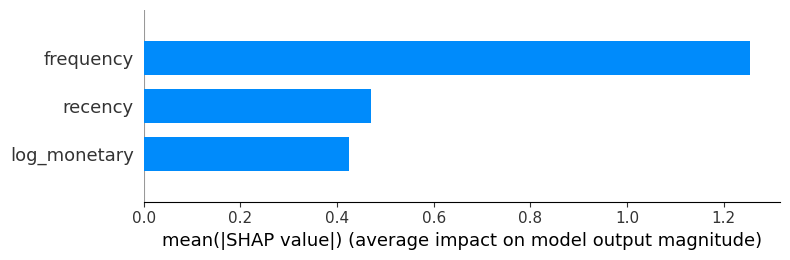

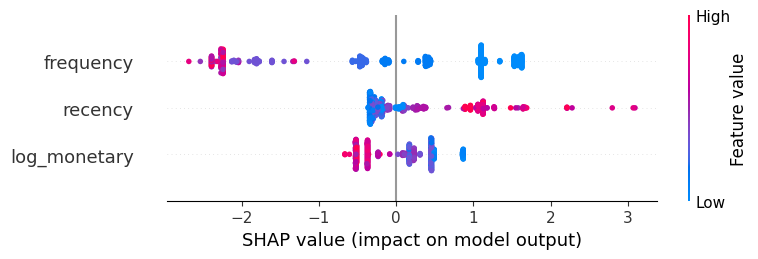


High-risk customer features: {'recency': 227.0, 'frequency': 1.0, 'log_monetary': 2.808}
Churn probability: 0.9359


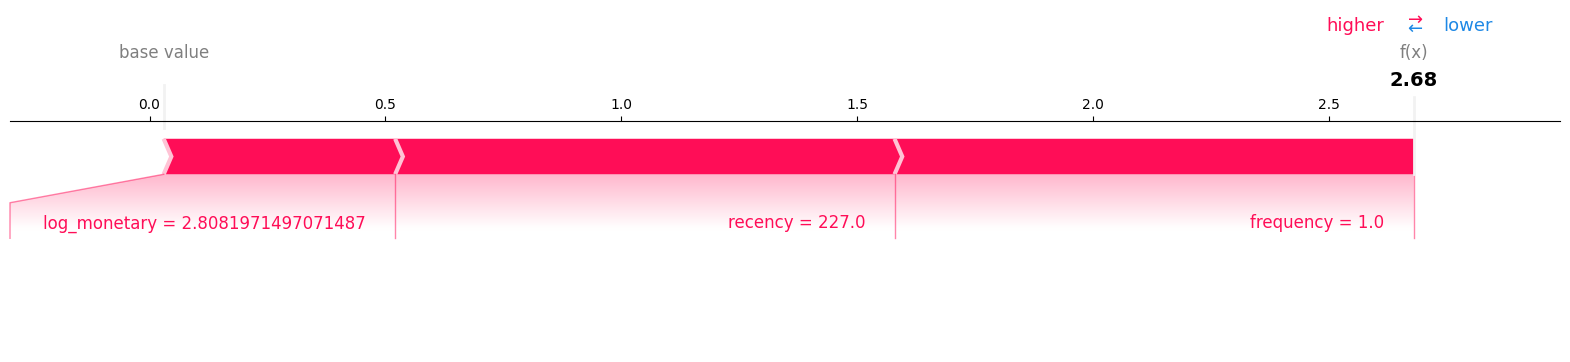

In [ ]:
explainer = shap.TreeExplainer(chosen_model)
shap_values = explainer.shap_values(X_test)

print("Global mean |SHAP| per feature:")
for feat, val in sorted(zip(feature_cols, abs(shap_values).mean(axis=0)), key=lambda x: -x[1]):
    print(f"  {feat:15s}: {val:.4f}")

shap.summary_plot(shap_values, X_test, feature_names=feature_cols, plot_type="bar")
shap.summary_plot(shap_values, X_test, feature_names=feature_cols)

high_risk_idx = chosen_model.predict_proba(X_test)[:, 1].argmax()
print(f"\nHigh-risk customer features: {dict(zip(feature_cols, X_test.iloc[high_risk_idx].round(3)))}")
print(f"Churn probability: {chosen_model.predict_proba(X_test)[high_risk_idx, 1]:.4f}")
shap.force_plot(explainer.expected_value, shap_values[high_risk_idx], X_test.iloc[high_risk_idx],
                feature_names=feature_cols, matplotlib=True)

## 12. ARM Latency (Android Device)

In [ ]:
assert os.path.exists("churn_model_edge.onnx"), "Rerun Section 10 first"
print(f"ONNX model on disk: {os.path.getsize('churn_model_edge.onnx')/1024:.1f} KB")

arm_results = {
    "device":            "[adb shell getprop ro.product.model]",
    "cpu":               "[adb shell getprop ro.board.platform]",
    "n_runs":            100,
    "sqlite_lookup_ms":  {"p50": None, "p95": None},
    "rfm_compute_ms":    {"p50": None, "p95": None},
    "onnx_inference_ms": {"p50": None, "p95": None},
    "end_to_end_ms":     {"p50": None, "p95": None},
}
print(json.dumps(arm_results, indent=2))
print("\nTarget: end-to-end p50 < 500ms")

ONNX model on disk: 4.9 KB
{
  "device": "[adb shell getprop ro.product.model]",
  "cpu": "[adb shell getprop ro.board.platform]",
  "n_runs": 100,
  "sqlite_lookup_ms": {
    "p50": null,
    "p95": null
  },
  "rfm_compute_ms": {
    "p50": null,
    "p95": null
  },
  "onnx_inference_ms": {
    "p50": null,
    "p95": null
  },
  "end_to_end_ms": {
    "p50": null,
    "p95": null
  }
}

Target: end-to-end p50 < 500ms
